# Libraries

In [164]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [165]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240527 - Ag60 GDE_0.6 M Na2SO4_pH1

10-Aug-26  07:19 PM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
06-Jun-26  09:46 PM    <DIR>          .ipynb_checkpoints
28-May-24  10:55 AM            33,608 0p6M_pH1 Na2SO4_20240528_0855_1min - Copy.xlsx
03-Aug-26  04:30 PM            46,210 0p6M_pH1 Na2SO4_20240528_0855_1min.xlsx
28-May-24  10:55 AM            10,975 0p6M_pH1 Na2SO4_20240528_0855_5min.xlsx
28-May-24  10:56 AM           271,146 0p6M_pH1 Na2SO4_20240528_0855_Line_1.csv
19-Jul-25  05:31 PM           768,045 20240527 - Ag60 GDE_0.6 M Na2SO4_pH1.ipynb
10-Aug-26  07:19 PM           656,510 20240527 - Ag60 GDE_0.6 M Na2SO4_pH1_CORRECTED.ipynb
10-Aug-26  07:16 PM               545 20240527_0.6 M Na2SO4_pH1_Energy Consumption.csv
03-Aug-26  05:58 PM             4,693 20240527_0.6M Na2SO4_pH1.csv
10-Aug-26  07:16 PM             1,404

# Load Data

In [220]:
Book = "Book_20240527 - Ag60 GDE_0.6 M Na2SO4_pH1.xlsx"
Book = pd.read_excel(Book)
Book.tail(10)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
34,Ag60 GDE in PTFE holder,60,78.320973,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-2.1,2024-05-28 08:07:43,13.874666,19.492453,...,0.189030,0.004989,0.805883,0.000098,0.933085,0.024628,NaN,0.957713,0.005647,83.5733
35,Ag60 GDE in PTFE holder,60,88.169229,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 08:22:43,14.124666,23.148328,...,0.226064,0.011210,0.762446,0.000280,0.850981,0.042196,NaN,0.893177,0.013264,NaN
36,Ag60 GDE in PTFE holder,60,87.519784,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 08:37:43,14.374666,25.318912,...,0.247899,0.013642,0.737986,0.000473,0.926301,0.050973,NaN,0.977274,0.016846,76.6649
37,Ag60 GDE in PTFE holder,60,88.012339,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 08:52:43,14.624666,25.605306,...,0.250946,0.013228,0.735368,0.000458,0.942963,0.049706,NaN,0.992669,0.016302,NaN
38,Ag60 GDE in PTFE holder,60,87.374897,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 09:07:44,14.874943,25.748147,...,0.252573,0.012607,0.734318,0.000502,0.942201,0.047030,NaN,0.989231,0.015676,NaN
39,Ag60 GDE in PTFE holder,60,88.026594,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 09:22:46,15.125499,25.869448,...,0.253888,0.012121,0.733451,0.000540,0.954172,0.045553,NaN,0.999725,0.015057,75.8761
40,Ag60 GDE in PTFE holder,60,88.297367,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 09:37:46,15.375499,26.008068,...,0.255301,0.011685,0.732379,0.000635,0.962433,0.044051,NaN,1.006484,0.014479,NaN
41,Ag60 GDE in PTFE holder,60,88.847554,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 09:52:45,15.625221,26.102759,...,0.256399,0.011310,0.731592,0.000699,0.972597,0.042903,NaN,1.015500,0.013929,75.5318
42,Ag60 GDE in PTFE holder,60,88.483838,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 10:07:46,15.875499,26.244540,...,0.257679,0.010608,0.731088,0.000626,0.973450,0.040073,NaN,1.013523,0.013189,NaN
43,Ag60 GDE in PTFE holder,60,73.621724,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 10:22:47,16.125777,20.867083,...,0.203405,0.005821,0.790385,0.000376,0.639349,0.018296,NaN,0.657645,0.006741,81.6350


In [221]:
# NOTE: do NOT rescale the Excel FE columns here.
# The old "FE * 100" line caused totals > 300% whenever this cell was
# re-run, and we recompute FE from scratch further down anyway.
Book.head(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,59.502913,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-27 18:15:14.204,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,NaN,0.000000,0.0,0.0000
1,Ag60 GDE in PTFE holder,60,62.083825,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-27 18:52:51.000,0.626888,1.562709,...,0.014568,0.0,0.984638,0.000214,0.957661,0.0,NaN,0.957661,0.0,105.6195
2,Ag60 GDE in PTFE holder,60,62.859213,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-27 19:23:53.000,1.144110,1.578421,...,0.014740,0.0,0.984738,0.000136,0.981076,0.0,NaN,0.981076,0.0,NaN


In [222]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
41,Ag60 GDE in PTFE holder,60,88.85,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 09:52:45,15.63,26.102759,...,0.011310,0.731592,0.000699,0.972597,0.042903,NaN,1.015500,0.013929,75.5318,88.85
42,Ag60 GDE in PTFE holder,60,88.48,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 10:07:46,15.88,26.244540,...,0.010608,0.731088,0.000626,0.973450,0.040073,NaN,1.013523,0.013189,NaN,88.48
43,Ag60 GDE in PTFE holder,60,73.62,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-28 10:22:47,16.13,20.867083,...,0.005821,0.790385,0.000376,0.639349,0.018296,NaN,0.657645,0.006741,81.6350,73.62


### Temp from pH meter

In [223]:
Temp = "2024-05-28_104955.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 25.278094390026713
Temp C median: 24.1


## Power Supply

In [224]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.tail(5)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
12016,40.00V,6.19V,1.500A,1.508A,320.00W,9.33W,NaN,NaN,NaN,On,CC,NaN,28.05.2024 10:56:42.528
12017,40.00V,6.18V,1.500A,1.505A,320.00W,9.30W,NaN,NaN,NaN,On,CC,NaN,28.05.2024 10:56:47.536
12018,40.00V,5.87V,1.500A,1.508A,320.00W,8.86W,NaN,NaN,NaN,On,CC,NaN,28.05.2024 10:56:52.531
12019,40.00V,5.93V,1.500A,1.514A,320.00W,8.98W,NaN,NaN,NaN,On,CC,NaN,28.05.2024 10:56:57.522
12020,40.00V,6.51V,1.500A,1.505A,320.00W,9.80W,NaN,NaN,NaN,On,CC,NaN,28.05.2024 10:57:02.285


In [225]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.17V
0.100A 1    2.10V
       2    2.24V

In [226]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-05-27 18:00:00     0.123      2.40
1 2024-05-27 20:00:00     0.272      2.91
2 2024-05-27 22:00:00     0.517      3.66
3 2024-05-28 00:00:00     0.770      4.74
4 2024-05-28 02:00:00     1.019      5.56
5 2024-05-28 04:00:00     1.516      6.92
6 2024-05-28 06:00:00     2.018      8.36
7 2024-05-28 08:00:00     3.016     10.59
8 2024-05-28 10:00:00     3.013     10.64


In [227]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-1].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-05-27 18:00:00     0.123      2.40
1 2024-05-27 20:00:00     0.272      2.91
2 2024-05-27 22:00:00     0.517      3.66
3 2024-05-28 00:00:00     0.770      4.74
4 2024-05-28 02:00:00     1.019      5.56
5 2024-05-28 04:00:00     1.516      6.92
6 2024-05-28 06:00:00     2.018      8.36
7 2024-05-28 08:00:00     3.016     10.59


In [228]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [229]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.123,2.40
0.272,2.91
0.517,3.66
0.770,4.74
1.019,5.56
1.516,6.92
2.018,8.36
3.016,10.59


In [230]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.123,2.40,1.23
0.272,2.91,2.72
0.517,3.66,5.17
0.770,4.74,7.70
1.019,5.56,10.19
1.516,6.92,15.16
2.018,8.36,20.18
3.016,10.59,30.16


## Flow rate

In [231]:
flow_rate = "0p6M_pH1 Na2SO4_20240528_0855_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-05-28 08:55:47.021000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p6M_pH1 Na2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [232]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-05-27 16:14:59.971000,59.502913,29.751456
1,2024-05-27 16:16:00.019000,61.083074,30.541537
2,2024-05-27 16:16:59.981000,60.966182,30.483091
3,2024-05-27 16:18:00.029000,61.112345,30.556172
4,2024-05-27 16:18:59.990000,61.422004,30.711002
...,...,...,...
965,2024-05-28 08:19:59.981000,73.547729,36.773865
966,2024-05-28 08:21:00.029000,73.906722,36.953361
967,2024-05-28 08:21:59.990000,73.621724,36.810862
968,2024-05-28 08:23:00.038000,73.898167,36.949083


In [233]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-05-27 16:00:00     59.502913     63.194194      62.262834   
1 2024-05-27 18:00:00     62.489444     65.117289      64.356449   
2 2024-05-27 20:00:00      64.17531     67.758292      66.371194   
3 2024-05-27 22:00:00     66.035848     69.523333      68.262108   
4 2024-05-28 00:00:00     67.936046     71.463708      70.095574   
5 2024-05-28 02:00:00     69.823585     75.621705      74.020731   
6 2024-05-28 04:00:00     73.828844     79.231714       77.83624   
7 2024-05-28 06:00:00     77.772583     88.946713      86.701128   
8 2024-05-28 08:00:00     73.547729     88.995029      83.138806   

  Flow_rate_median  
0        62.265672  
1        64.522189  
2        66.568685  
3        68.429268  
4        70.293761  
5        74.396524  
6        78.243746  
7        87.793841  
8         88.32669  


#### Correction dry flow

In [234]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.390 L/mol
p_sat = 3.0025 kPa -> x(H2O) = 2.96 % -> dry factor 0.97037


In [235]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [236]:
print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-05-27 16:00:00     59.502913     63.194194      62.262834   
1 2024-05-27 18:00:00     62.489444     65.117289      64.356449   
2 2024-05-27 20:00:00      64.17531     67.758292      66.371194   
3 2024-05-27 22:00:00     66.035848     69.523333      68.262108   
4 2024-05-28 00:00:00     67.936046     71.463708      70.095574   
5 2024-05-28 02:00:00     69.823585     75.621705      74.020731   
6 2024-05-28 04:00:00     73.828844     79.231714       77.83624   
7 2024-05-28 06:00:00     77.772583     88.946713      86.701128   
8 2024-05-28 08:00:00     73.547729     88.995029      83.138806   

  Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0        62.265672         57.739723         61.321624          60.417862   
1        64.522189         60.637757         63.187734          62.449439   
2        66.568685         62.273668         65.750479          64.404483   
3        68

In [237]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-1].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-05-27 16:00:00,59.502913,63.194194,62.262834,62.265672,57.739723,61.321624,60.417862,60.420616,0.123,2.40
1,2024-05-27 18:00:00,62.489444,65.117289,64.356449,64.522189,60.637757,63.187734,62.449439,62.610268,0.272,2.91
2,2024-05-27 20:00:00,64.17531,67.758292,66.371194,66.568685,62.273668,65.750479,64.404483,64.596122,0.517,3.66
3,2024-05-27 22:00:00,66.035848,69.523333,68.262108,68.429268,64.079074,67.463218,66.239365,66.401572,0.770,4.74
4,2024-05-28 00:00:00,67.936046,71.463708,70.095574,70.293761,65.922965,69.346096,68.018503,68.210817,1.019,5.56
5,2024-05-28 02:00:00,69.823585,75.621705,74.020731,74.396524,67.754573,73.380883,71.827349,72.192007,1.516,6.92
6,2024-05-28 04:00:00,73.828844,79.231714,77.83624,78.243746,71.641148,76.88392,75.529797,75.925228,2.018,8.36
7,2024-05-28 06:00:00,77.772583,88.946713,86.701128,87.793841,75.468026,86.311044,84.132001,85.192334,3.016,10.59


In [240]:
# dfflow_rate.to_csv('20240527_0.6M Na2SO4_pH1_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J <br>

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [241]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.123,2.40,1.23,123.0
0.272,2.91,2.72,272.0
0.517,3.66,5.17,517.0


In [242]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.123,2.40,1.23,123.0,2125.440
0.272,2.91,2.72,272.0,5698.944
0.517,3.66,5.17,517.0,13623.984
0.770,4.74,7.70,770.0,26278.560
1.019,5.56,10.19,1019.0,40792.608
1.516,6.92,15.16,1516.0,75533.184
2.018,8.36,20.18,2018.0,121467.456
3.016,10.59,30.16,3016.0,229963.968


In [243]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.123,2.40,1.23,123.0,2125.440,0.000590
0.272,2.91,2.72,272.0,5698.944,0.001583
0.517,3.66,5.17,517.0,13623.984,0.003784
0.770,4.74,7.70,770.0,26278.560,0.007300
1.019,5.56,10.19,1019.0,40792.608,0.011331
1.516,6.92,15.16,1516.0,75533.184,0.020981
2.018,8.36,20.18,2018.0,121467.456,0.033741
3.016,10.59,30.16,3016.0,229963.968,0.063879


In [246]:
# dfcell_voltage.to_csv('20240527_0.6 M Na2SO4_pH1_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [247]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,59.50,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-27 18:15:14.204,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0000,59.50,0.0
1,Ag60 GDE in PTFE holder,60,62.08,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-27 18:52:51.000,0.63,1.562709,...,0.984638,0.000214,0.957661,0.000000,NaN,0.957661,0.000000,105.6195,62.08,0.0
2,Ag60 GDE in PTFE holder,60,62.86,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-27 19:23:53.000,1.14,1.578421,...,0.984738,0.000136,0.981076,0.000000,NaN,0.981076,0.000000,NaN,62.86,1.0
3,Ag60 GDE in PTFE holder,60,63.19,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-27 19:53:53.000,1.64,1.577097,...,0.985135,0.000046,0.984225,0.000000,NaN,0.984225,0.000000,105.6232,63.19,1.0
4,Ag60 GDE in PTFE holder,60,64.74,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-27 20:23:54.000,2.14,2.489011,...,0.976566,0.000042,0.738227,0.000000,NaN,0.738227,0.000000,NaN,64.74,2.0
5,Ag60 GDE in PTFE holder,60,64.63,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-27 20:53:54.000,2.64,3.296444,...,0.968973,0.000026,0.980258,0.000000,NaN,0.980258,0.000000,103.2363,64.63,2.0
6,Ag60 GDE in PTFE holder,60,64.66,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-27 21:23:54.000,3.14,3.318494,...,0.968891,0.000000,0.986021,0.000000,NaN,0.986021,0.000000,NaN,64.66,3.0
7,Ag60 GDE in PTFE holder,60,64.95,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-27 21:55:26.000,3.67,3.326144,...,0.968757,0.000000,0.994727,0.000000,NaN,0.994727,0.000000,103.1351,64.95,3.0
8,Ag60 GDE in PTFE holder,60,67.76,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-27 22:26:56.000,4.19,5.216969,...,0.950748,0.000000,0.849410,0.000000,NaN,0.849410,0.000000,NaN,67.76,4.0
9,Ag60 GDE in PTFE holder,60,66.94,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-27 22:58:27.000,4.72,5.991551,...,0.942999,0.000000,0.971198,0.000000,NaN,0.971198,0.000000,99.1219,66.94,4.0


## Current Density

In [248]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,59.50,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-27 18:15:14.204,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0000,59.50,0.0,0.0
1,Ag60 GDE in PTFE holder,60,62.08,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-27 18:52:51.000,0.63,1.562709,...,0.000214,0.957661,0.000000,NaN,0.957661,0.000000,105.6195,62.08,0.0,-125.0
2,Ag60 GDE in PTFE holder,60,62.86,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-27 19:23:53.000,1.14,1.578421,...,0.000136,0.981076,0.000000,NaN,0.981076,0.000000,NaN,62.86,1.0,-125.0
3,Ag60 GDE in PTFE holder,60,63.19,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-27 19:53:53.000,1.64,1.577097,...,0.000046,0.984225,0.000000,NaN,0.984225,0.000000,105.6232,63.19,1.0,-125.0
4,Ag60 GDE in PTFE holder,60,64.74,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-27 20:23:54.000,2.14,2.489011,...,0.000042,0.738227,0.000000,NaN,0.738227,0.000000,NaN,64.74,2.0,-270.0
5,Ag60 GDE in PTFE holder,60,64.63,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-27 20:53:54.000,2.64,3.296444,...,0.000026,0.980258,0.000000,NaN,0.980258,0.000000,103.2363,64.63,2.0,-270.0
6,Ag60 GDE in PTFE holder,60,64.66,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-27 21:23:54.000,3.14,3.318494,...,0.000000,0.986021,0.000000,NaN,0.986021,0.000000,NaN,64.66,3.0,-270.0
7,Ag60 GDE in PTFE holder,60,64.95,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-27 21:55:26.000,3.67,3.326144,...,0.000000,0.994727,0.000000,NaN,0.994727,0.000000,103.1351,64.95,3.0,-270.0
8,Ag60 GDE in PTFE holder,60,67.76,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-27 22:26:56.000,4.19,5.216969,...,0.000000,0.849410,0.000000,NaN,0.849410,0.000000,NaN,67.76,4.0,-520.0
9,Ag60 GDE in PTFE holder,60,66.94,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-27 22:58:27.000,4.72,5.991551,...,0.000000,0.971198,0.000000,NaN,0.971198,0.000000,99.1219,66.94,4.0,-520.0


## FE(CO)

In [249]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [250]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.390 L/mol


In [251]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.123, 0.272, 0.517, 0.77, 1.019, 1.516, 2.018, 3.016]

In [252]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[4, 4, 4, 6, 5, 5, 7, 8]

In [253]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.123                0.015  0.000
0.272                0.031  0.000
0.517                0.057  0.000
0.770                0.083  0.000
1.019                0.107  0.000
1.516                0.150  0.002
2.018                0.189  0.005
3.016                0.253  0.012


In [254]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 99.9 / 90.7 %


In [255]:
# rows[rows["FE(total)"]>100 ]

### Mean FE per current density

In [256]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        123   71.281369    0.000000     94.822488      0.000000  23.761694   
1        272   88.443125    0.000000     94.168777      0.000000   5.949296   
2        517   91.124483    0.000000     94.199808      0.000000   3.333080   
3        770   89.056401    0.000000     94.026697      0.000000   4.684902   
4       1019   93.589633    0.023547     94.118443      0.022033   0.800645   
5       1516   91.413698    0.926174     93.917343      1.008648   2.611929   
6       2018   90.965626    2.249938     93.781790      2.481449   2.716886   
7       3016   93.152651    4.488750     94.320931      4.433539   1.342879   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   0.000000  47.523389   0.000000  70.774293  ...   0.011005     0.014639  4   
1   0.000000  11.898592   0.000000  88.085644  ...   0.029138     0.031025  4   
2   0.000000   6.666159   0.000000  90.720258

## FE(H2)

In [257]:
print(rows["FE(H2)"])

0      0.000000
1     94.365724
2     95.480502
3     95.279252
4     70.604132
5     93.912815
6     94.424738
7     94.830814
8     94.952658
9     94.487825
10    93.911791
11    81.145658
12    65.714164
13    91.834217
14    94.046080
15    94.007314
16    94.493718
17    94.242915
18    94.878220
19    94.118443
20    94.783766
21    90.515438
22    93.652301
23    81.003604
24    93.249197
25    93.917343
26    94.386167
27    94.512178
28    93.662955
29    93.781790
30    93.933734
31    94.283410
32    92.274025
33    74.732395
34    94.091071
35    94.565921
36    95.092132
37    94.075940
38    95.501348
39    92.335303
40    84.202402
41    93.470160
42    95.978000
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

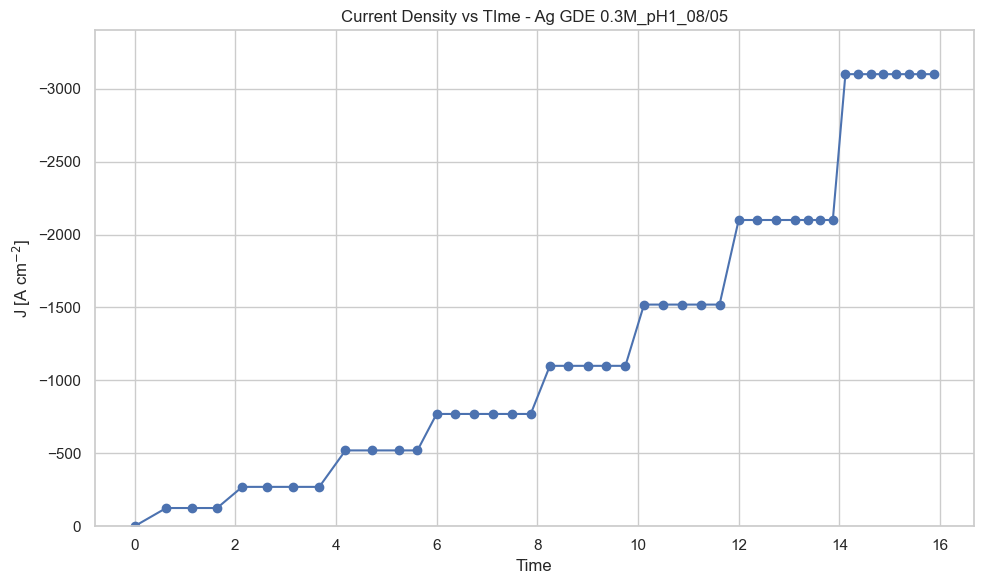

In [258]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.3M_pH1_08/05')  
plt.xlabel('Time') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

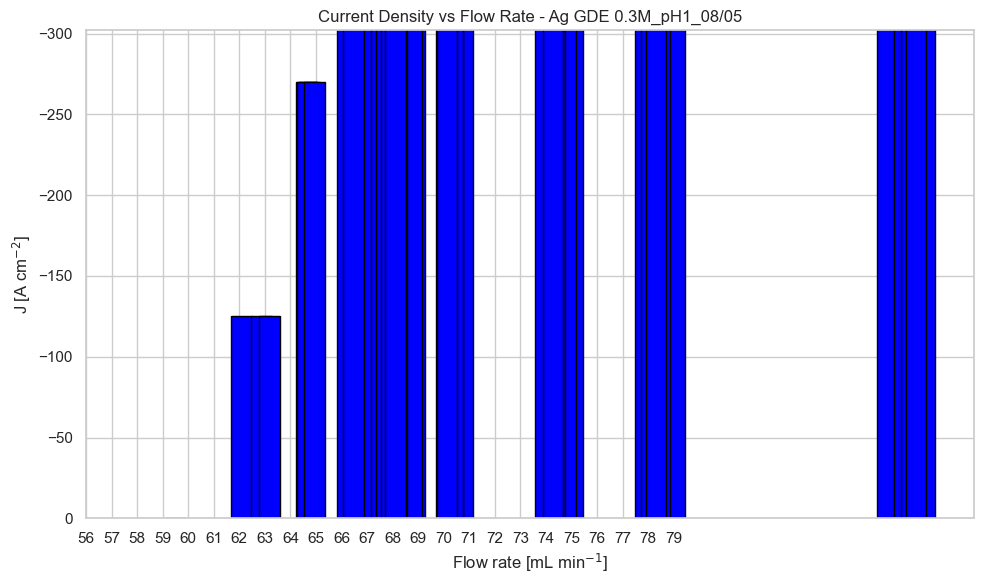

In [259]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Current Density'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.3M_pH1_08/05')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -302)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


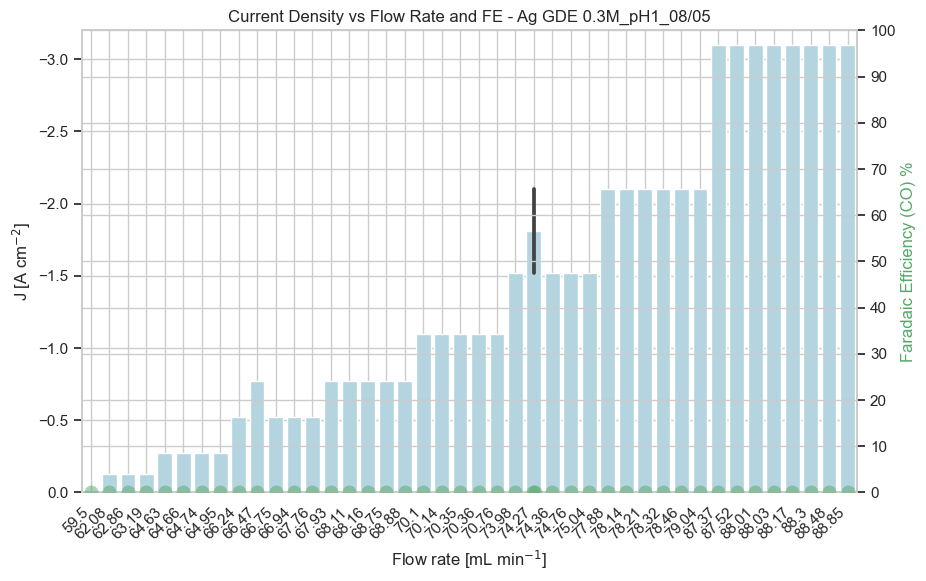

In [260]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.3M_pH1_08/05')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240508_Ag_GDE_0_3M_pH1_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [261]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [262]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240527 - Ag60 GDE_0.6 M Na2SO4_pH1

11-Aug-26  08:13 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
06-Jun-26  09:46 PM    <DIR>          .ipynb_checkpoints
28-May-24  10:55 AM            33,608 0p6M_pH1 Na2SO4_20240528_0855_1min - Copy.xlsx
03-Aug-26  04:30 PM            46,210 0p6M_pH1 Na2SO4_20240528_0855_1min.xlsx
28-May-24  10:55 AM            10,975 0p6M_pH1 Na2SO4_20240528_0855_5min.xlsx
28-May-24  10:56 AM           271,146 0p6M_pH1 Na2SO4_20240528_0855_Line_1.csv
19-Jul-25  05:31 PM           768,045 20240527 - Ag60 GDE_0.6 M Na2SO4_pH1.ipynb
11-Aug-26  08:13 AM           651,969 20240527 - Ag60 GDE_0.6 M Na2SO4_pH1_CORRECTED.ipynb
11-Aug-26  08:13 AM               545 20240527_0.6 M Na2SO4_pH1_Energy Consumption.csv
10-Aug-26  07:25 PM             5,045 20240527_0.6M Na2SO4_pH1.csv
11-Aug-26  08:13 AM             1,404

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


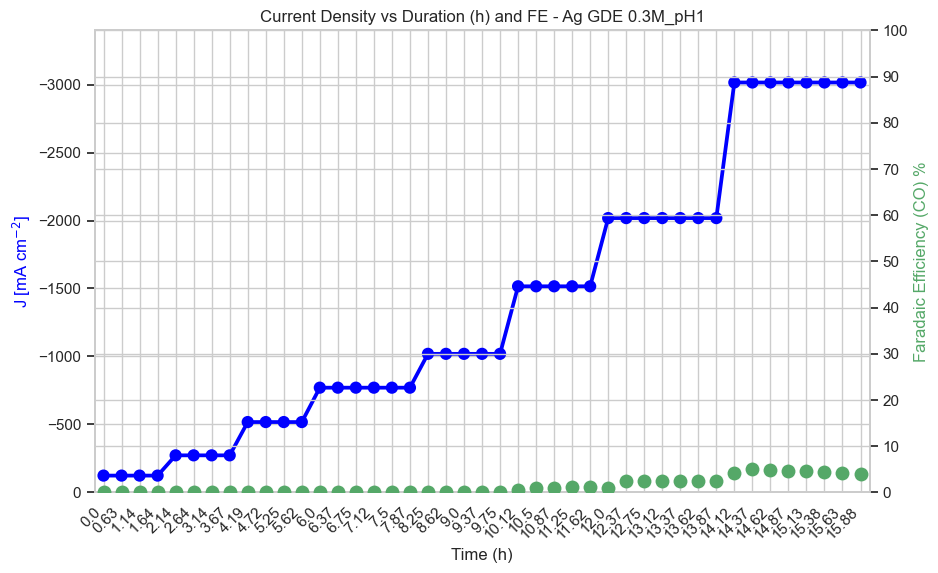

In [263]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.3M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240508_Ag_GDE_0_3M_pH1_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

## Stacked bar plot

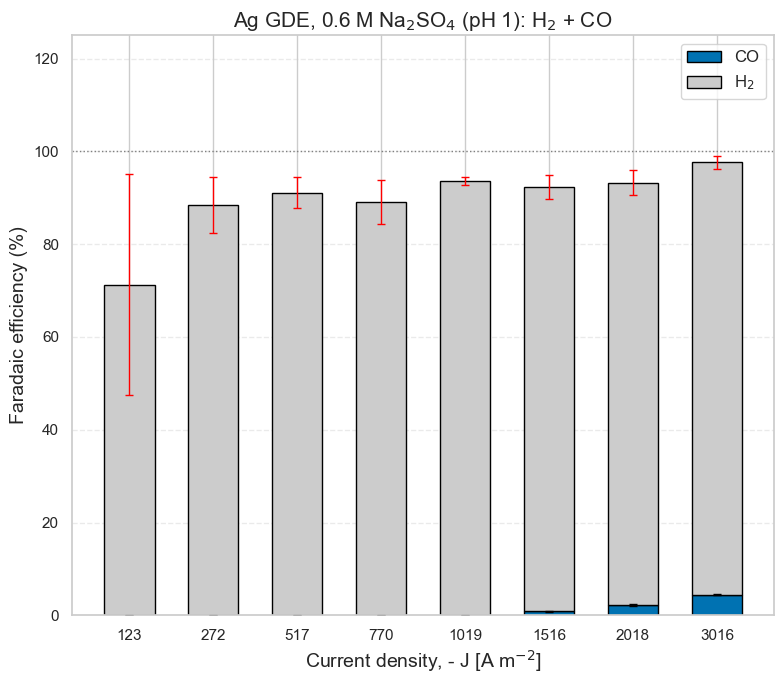

In [264]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M Na$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

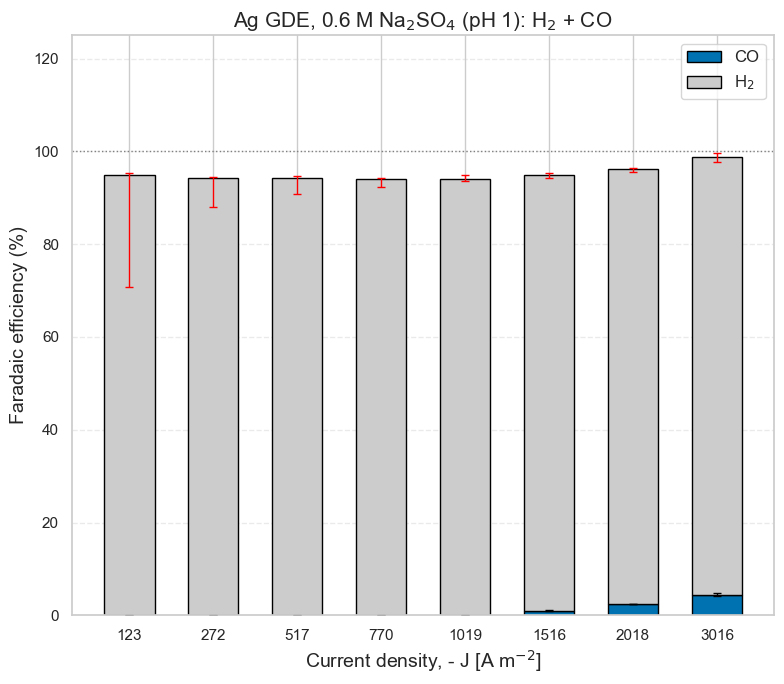

In [267]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M Na$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [268]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [269]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,71.281369,0.000000,94.822488,0.000000,23.761694,0.000000,47.523389,0.000000,70.774293,...,0.014639,4,24.048195,0.507077,0.000000,0.000000,24.048195,0.507077,0–2,123
1,250,88.443125,0.000000,94.168777,0.000000,5.949296,0.000000,11.898592,0.000000,88.085644,...,0.031025,4,6.083132,0.357481,0.000000,0.000000,6.083132,0.357481,2–4,272
2,500,91.124483,0.000000,94.199808,0.000000,3.333080,0.000000,6.666159,0.000000,90.720258,...,0.057176,4,3.479550,0.404225,0.000000,0.000000,3.479550,0.404225,4–6,517
3,750,89.056401,0.000000,94.026697,0.000000,4.684902,0.000000,11.475618,0.000000,92.377492,...,0.082688,6,1.649205,0.167009,0.000000,0.000000,1.649205,0.167009,6–8,770
4,1000,93.589633,0.023547,94.118443,0.022033,0.800645,0.001883,1.790297,0.004211,93.652301,...,0.106628,5,0.466142,0.665323,0.000651,0.003674,0.457828,0.669648,8–10,1019
5,1500,91.413698,0.926174,93.917343,1.008648,2.611929,0.107834,5.840452,0.241124,93.249197,...,0.149566,5,0.668145,0.468824,0.004905,0.040439,0.673050,0.509263,10–12,1516
6,2000,90.965626,2.249938,93.781790,2.481449,2.716886,0.236624,7.188206,0.626048,92.968490,...,0.189030,7,0.813300,0.230612,0.007958,0.011315,0.811948,0.259428,12–14,2018
7,3000,93.152651,4.488750,94.320931,4.433539,1.342879,0.138149,3.798236,0.390746,93.186446,...,0.253230,8,1.134485,0.873505,0.230175,0.320078,0.774161,0.585741,14–16,3016


In [272]:
Res_Book
# Res_Book.to_csv('20240527_0.6M Na2SO4_pH1.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,71.281369,0.000000,94.822488,0.000000,23.761694,0.000000,47.523389,0.000000,70.774293,...,0.014639,4,24.048195,0.507077,0.000000,0.000000,24.048195,0.507077,0–2,123
1,250,88.443125,0.000000,94.168777,0.000000,5.949296,0.000000,11.898592,0.000000,88.085644,...,0.031025,4,6.083132,0.357481,0.000000,0.000000,6.083132,0.357481,2–4,272
2,500,91.124483,0.000000,94.199808,0.000000,3.333080,0.000000,6.666159,0.000000,90.720258,...,0.057176,4,3.479550,0.404225,0.000000,0.000000,3.479550,0.404225,4–6,517
3,750,89.056401,0.000000,94.026697,0.000000,4.684902,0.000000,11.475618,0.000000,92.377492,...,0.082688,6,1.649205,0.167009,0.000000,0.000000,1.649205,0.167009,6–8,770
4,1000,93.589633,0.023547,94.118443,0.022033,0.800645,0.001883,1.790297,0.004211,93.652301,...,0.106628,5,0.466142,0.665323,0.000651,0.003674,0.457828,0.669648,8–10,1019
5,1500,91.413698,0.926174,93.917343,1.008648,2.611929,0.107834,5.840452,0.241124,93.249197,...,0.149566,5,0.668145,0.468824,0.004905,0.040439,0.673050,0.509263,10–12,1516
6,2000,90.965626,2.249938,93.781790,2.481449,2.716886,0.236624,7.188206,0.626048,92.968490,...,0.189030,7,0.813300,0.230612,0.007958,0.011315,0.811948,0.259428,12–14,2018
7,3000,93.152651,4.488750,94.320931,4.433539,1.342879,0.138149,3.798236,0.390746,93.186446,...,0.253230,8,1.134485,0.873505,0.230175,0.320078,0.774161,0.585741,14–16,3016


## Mean and StD of FE(CO) through time

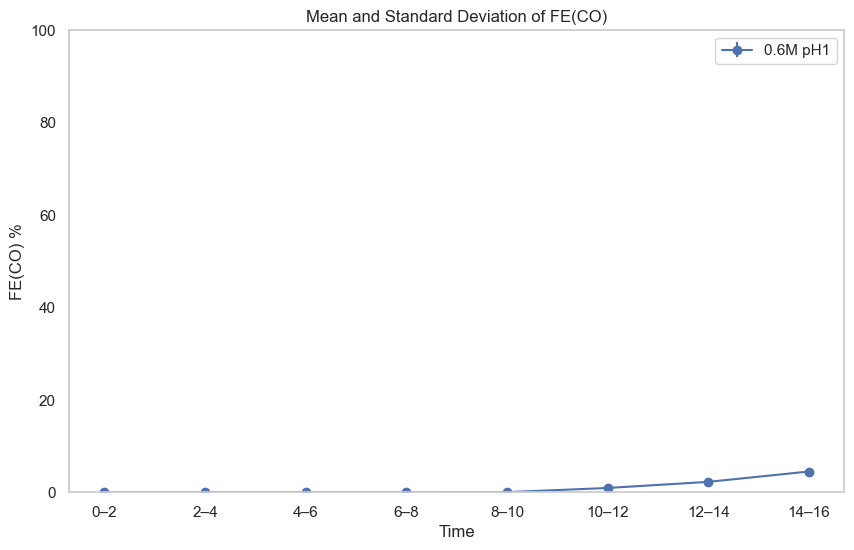

In [273]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Applied Current mean with standard deviation
# ax.errorbar(resampled_df.index, resampled_df['Applied current / A_mean'], 
#             yerr=resampled_df['Applied current / A_std'], fmt='-o', label='Applied current / A_mean')

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.6M pH1')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240508_0.3M_pH1_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

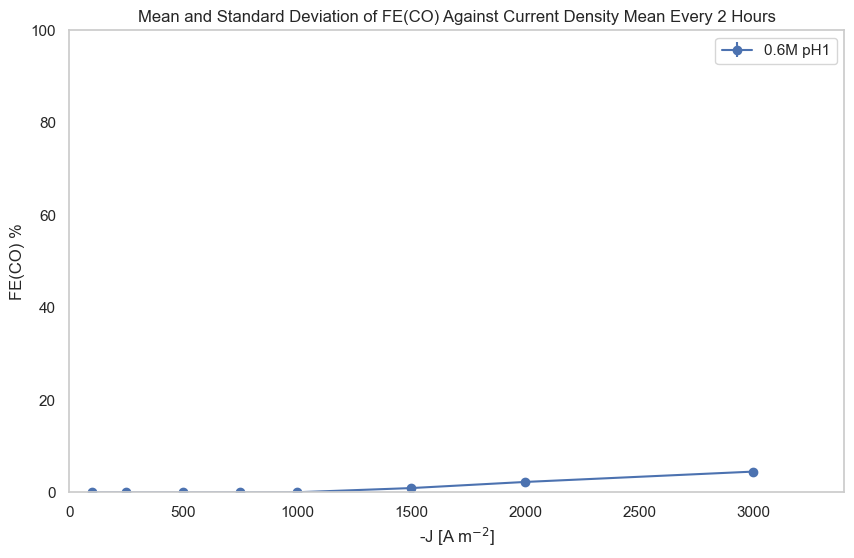

In [274]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.6M pH1')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3400)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240527_0.6M_pH1_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()

In [275]:
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot FE (CO) mean with standard deviation against Applied Current mean
# ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(H2)_mean'], 
#             yerr=Res_Book['FE(H2)_sem'], fmt='-o', label='0.3M pH2')

# # Formatting the plot
# ax.set_xlabel(r'-J [A m$^{-2}$]')
# ax.set_ylabel('FE(H2) %')
# ax.set_xlim(0,3400)
# ax.set_ylim(0,140)
# ax.set_title('Mean and Standard Deviation of FE(H2) Against Current Density Mean Every 2 Hours')
# ax.legend()
# ax.grid(False)

# # plt.savefig('20240508_0.3M_pH1_mean_std_FE(H2)vsCD.png', dpi=300, bbox_inches='tight')
# plt.show()